# Tutorial 4

In this tutorial, we'll look at sequence modelling and natural language processing. We'll start with recurrent networks (RNN, LSTM), then introduce attention and the transformer encoder, and finish by fine-tuning a pre-trained transformer model from HuggingFace.

```sh
$ uv add datasets gensim transformers
```

In [1]:
import math
import re
from collections import Counter

import numpy as np
from matplotlib import pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset

from transformers import AutoTokenizer, AutoModelForSequenceClassification

print("Torch version:", torch.__version__)

/home/marekdedic/Documents/git/ni-tzn/tutorials/files/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Torch version: 2.10.0+cu128


## The sequence modelling problem

Processing sequential data is hard for two reasons:
- Sequences usually have differing lengths and we need a way to feed them into a network that expects fixed-size inputs
- The meaning of a token can depend on tokens that are very far away &mdash; in the sentence *"The movie that I watched yesterday with my friend was amazing"*, the word *"amazing"* refers to *"movie"* with seven words in between.

We'll work with the [IMDB sentiment dataset](https://huggingface.co/datasets/stanfordnlp/imdb): 50&thinsp;000 movie reviews labelled positive or negative. The task is binary classification.


In [2]:
# Take a small subset so everything trains in a few minutes on CPU
raw = load_dataset("stanfordnlp/imdb")
train_full = raw["train"].shuffle(seed=42).select(range(5000))
test_full = raw["test"].shuffle(seed=42).select(range(1000))

# Split a validation set off the training data
split = train_full.train_test_split(test_size=0.2, seed=42)
train_ds = split["train"]
val_ds = split["test"]
test_ds = test_full

print(f"train: {len(train_ds)}, val: {len(val_ds)}, test: {len(test_ds)}")
print()
print("Example review (label =", train_ds[0]["label"], "):")
print(train_ds[0]["text"][:400], "...")

train: 4000, val: 1000, test: 1000

Example review (label = 0 ):
This movie is just truly awful, the eye-candy that plays Ben just can make up for everything else that is wrong with this movie.<br /><br />The writer/director/producer/lead actor etc probably had a good idea to create a movie dealing with the important issues of gay marriage, family acceptance, religion, homophobia, hate crimes and just about every other issue effecting a gay man of these times,  ...


## Tokenisation

To feed text into a neural network, we first need to turn it into integers. We'll start with a very simple word-level tokeniser and a vocabulary built from the most frequent words in the training set. Later in the tutorial we'll see what modern tokenisers 
look like.


In [3]:
def tokenize(text):
    return re.findall(r"[a-z']+", text.lower())

VOCAB_SIZE = 5000
PAD, UNK = 0, 1

counter = Counter()
for ex in train_ds:
    counter.update(tokenize(ex["text"]))

vocab = {"<pad>": PAD, "<unk>": UNK}
for word, _ in counter.most_common(VOCAB_SIZE - 2):
    vocab[word] = len(vocab)

print(f"Vocabulary size: {len(vocab)}")
print("First 10 most common tokens:", list(vocab.items())[2:12])

Vocabulary size: 5000
First 10 most common tokens: [('the', 2), ('and', 3), ('a', 4), ('of', 5), ('to', 6), ('is', 7), ('br', 8), ('in', 9), ('it', 10), ('i', 11)]


Reviews vary a lot in length, so we'll pad or truncate every sequence to a fixed length. Let's first look at the distribution of lengths to pick a reasonable cut-off.

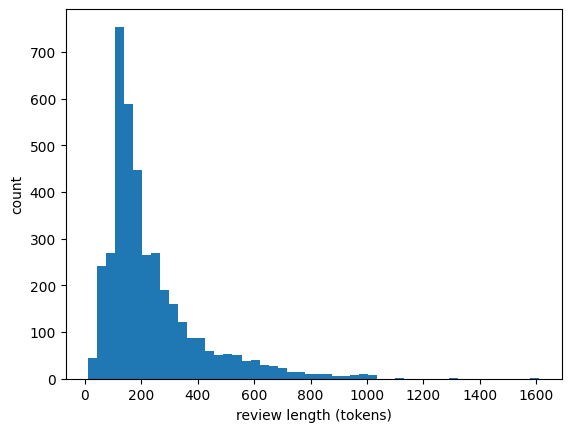

median: 177   95th percentile: 606


In [4]:
lengths = np.array([len(tokenize(ex["text"])) for ex in train_ds])
plt.hist(lengths, bins=50)
plt.xlabel("review length (tokens)")
plt.ylabel("count")
plt.show()
print("median:", int(np.median(lengths)), "  95th percentile:", int(np.percentile(lengths, 95)))

In [5]:
SEQ_LEN = 256

def encode(text):
    ids = [vocab.get(t, UNK) for t in tokenize(text)][:SEQ_LEN]
    ids = ids + [PAD] * (SEQ_LEN - len(ids))
    return ids

class IMDBDataset(Dataset):
    def __init__(self, hf_split):
        self.x = torch.tensor([encode(ex["text"]) for ex in hf_split], dtype=torch.long)
        self.y = torch.tensor([ex["label"] for ex in hf_split], dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.x[i], self.y[i]

train_data = IMDBDataset(train_ds)
val_data = IMDBDataset(val_ds)
test_data = IMDBDataset(test_ds)

batch_size = 64
dl_train = DataLoader(train_data, batch_size=batch_size, shuffle=True)
dl_val = DataLoader(val_data, batch_size=batch_size)
dl_test = DataLoader(test_data, batch_size=batch_size)

print("train tensor shape:", train_data.x.shape)

train tensor shape: torch.Size([4000, 256])


Let's define a couple of helper functions to train and evaluate models:

In [6]:
def calculate_loss_accuracy(model, dataloader):
    model.eval()
    correct, total, loss_sum = 0, 0, 0.0
    loss_fn = nn.CrossEntropyLoss(reduction="sum")
    with torch.no_grad():
        for x, y in dataloader:
            logits = model(x)
            loss_sum += loss_fn(logits, y).item()
            correct += (logits.argmax(1) == y).sum().item()
            total += y.numel()
    return loss_sum / total, correct / total

def train_model(model, epochs, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    for epoch in range(epochs):
        model.train()
        for x, y in dl_train:
            logits = model(x)
            loss = loss_fn(logits, y)
            loss.backward()
            opt.step()
            opt.zero_grad()
        val_loss, val_acc = calculate_loss_accuracy(model, dl_val)
        print(f"epoch {epoch+1:>2d}/{epochs:>2d}  val loss: {val_loss:.4f}  val acc: {val_acc:.3f}")

## Recurrent neural networks

A recurrent network processes the sequence one token at a time, maintaining a hidden state that summarises what it has seen so far:

$$h_t = \tanh(W_{xh} x_t + W_{hh} h_{t-1} + b)$$

PyTorch provides `nn.RNN` and `nn.LSTM`, but let's implement a vanilla RNN cell ourselves.

### Task 1

Implement a single RNN cell as an `nn.Module`. The forward pass should take an input vector $x_t$ and the previous hidden state $h_{t-1}$, and return the new hidden state $h_t$ according to the formula above.


In [7]:
class VanillaRNNCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.W_xh = nn.Linear(input_size, hidden_size)
        self.W_hh = nn.Linear(hidden_size, hidden_size, bias=False)

    def forward(self, x_t, h_prev):
        return torch.tanh(self.W_xh(x_t) + self.W_hh(h_prev))

We'll wrap the cell into a full sentiment classifier that embeds the tokens, runs the recurrence over the sequence, and uses the final hidden state to predict the label.

In practice, vanilla RNNs are hard to train on long sequences because gradients vanish (or explode) as they flow back through many time steps. We'll see this empirically and then move on to LSTMs, which were invented to fix exactly this problem.

In [8]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden_size=64, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD)
        self.cell = VanillaRNNCell(embed_dim, hidden_size)
        self.head = nn.Linear(hidden_size, num_classes)
        self.hidden_size = hidden_size

    def forward(self, x):
        # x: (batch, seq_len)
        emb = self.embedding(x)  # (batch, seq_len, embed_dim)
        h = torch.zeros(x.size(0), self.hidden_size, device=x.device)
        for t in range(emb.size(1)):
            h = self.cell(emb[:, t], h)
        return self.head(h)

torch.manual_seed(0)
rnn_model = RNNClassifier(len(vocab))
train_model(rnn_model, epochs=3)
test_loss, test_acc = calculate_loss_accuracy(rnn_model, dl_test)
print(f"RNN test accuracy: {test_acc:.3f}")

epoch  1/ 3  val loss: 0.6998  val acc: 0.479
epoch  2/ 3  val loss: 0.7010  val acc: 0.471
epoch  3/ 3  val loss: 0.7051  val acc: 0.499
RNN test accuracy: 0.507


## LSTM

The [LSTM (long short-term memory)](https://colah.github.io/posts/2015-08-Understanding-LSTMs/) cell extends the vanilla RNN with three gates (input, forget, output) and a separate cell state, which together let the network learn long-range dependencies far more reliably than a plain RNN.

In [9]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_size=128, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD)
        self.lstm = nn.LSTM(embed_dim, hidden_size, batch_first=True)
        self.head = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        out, (h_n, _) = self.lstm(emb)
        return self.head(h_n.squeeze(0))

torch.manual_seed(0)
lstm_model = LSTMClassifier(len(vocab))
train_model(lstm_model, epochs=3)
lstm_test_loss, lstm_test_acc = calculate_loss_accuracy(lstm_model, dl_test)
print(f"LSTM test accuracy: {lstm_test_acc:.3f}")

epoch  1/ 3  val loss: 0.6951  val acc: 0.485
epoch  2/ 3  val loss: 0.7000  val acc: 0.513
epoch  3/ 3  val loss: 0.7089  val acc: 0.491
LSTM test accuracy: 0.515


## word2vec

In the LSTM above we used `nn.Embedding` to map tokens to vectors, with the embedding weights learned end-to-end as part of the classifier. An alternative is to learn the embeddings separately, on a *self-supervised* objective: predict a word from its context (or the context from a word). The resulting vectors, known as **word2vec** embeddings, capture semantic information &mdash; words used in similar contexts end up near each other in the latent space.

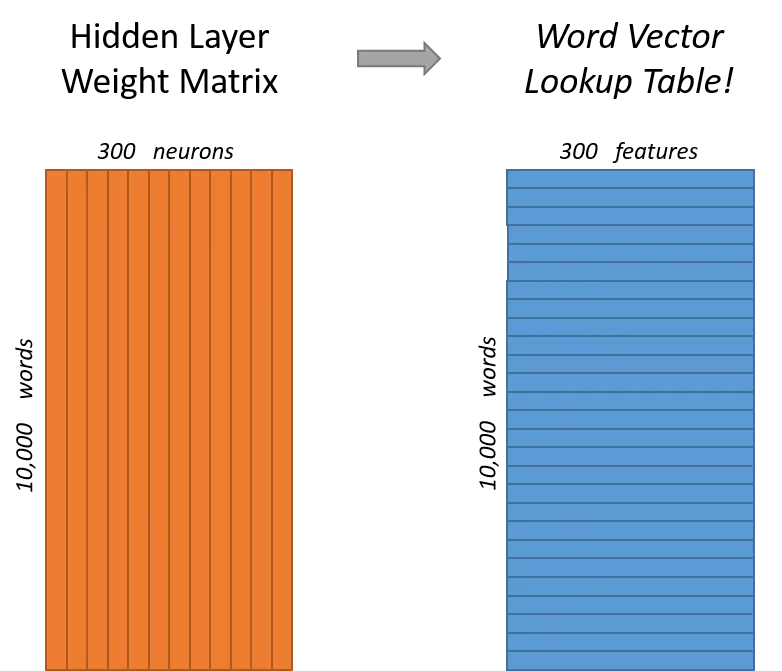

([source](https://medium.com/@manansuri/a-dummys-guide-to-word2vec-456444f3c673))

In the latent space, dimensions often carry interpretable semantic structure:

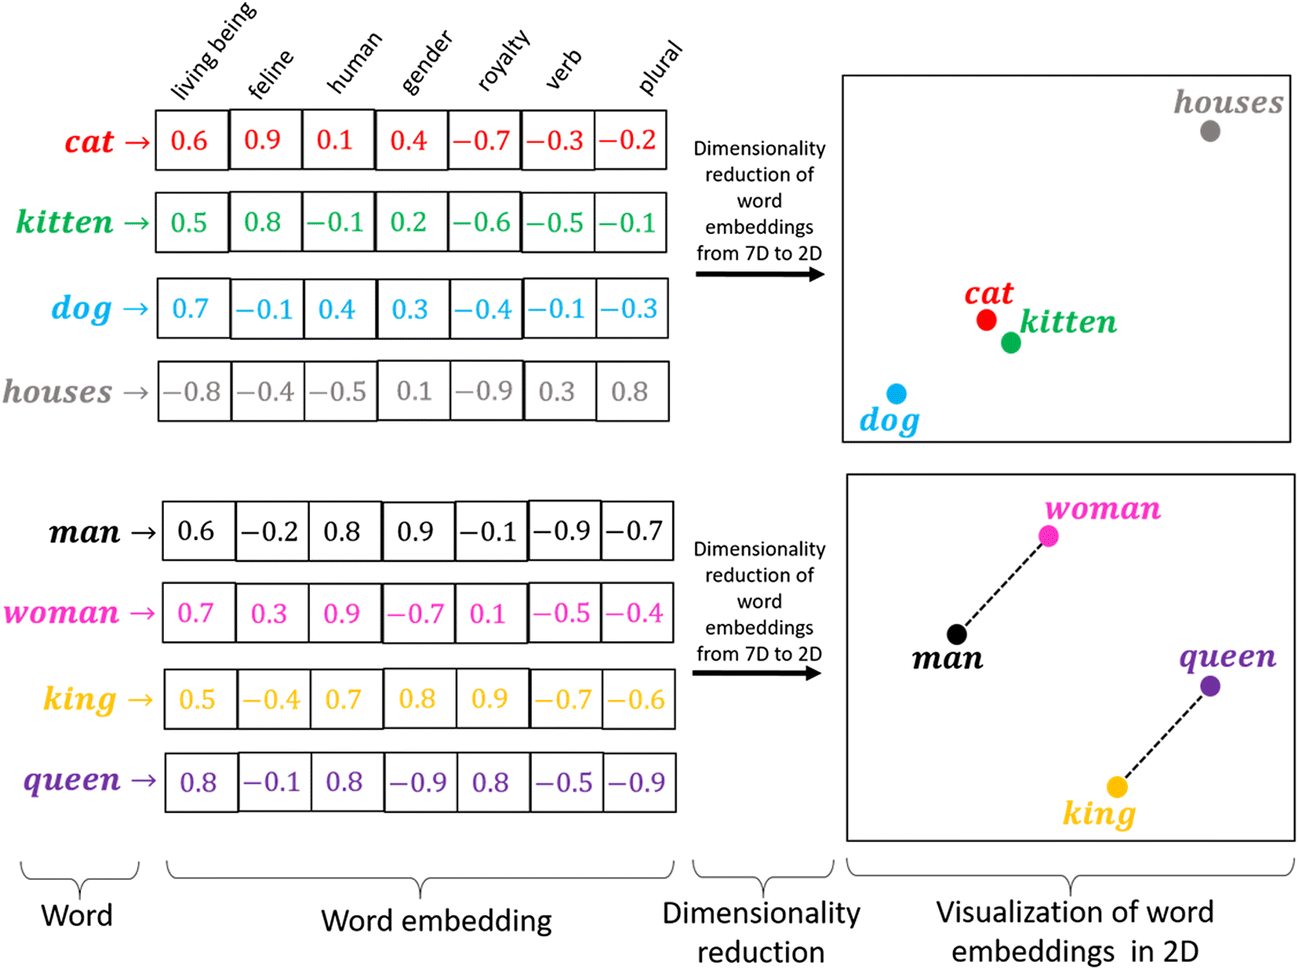

([source](https://www.analyticsvidhya.com/blog/2021/07/feature-extraction-and-embeddings-in-nlp-a-beginners-guide-to-understand-natural-language-processing/))

There are two flavours of word2vec: **CBOW** (continuous bag-of-words) predicts a target word from its surrounding context, while **skip-gram** does the opposite &mdash; it predicts the context words from a central target word:

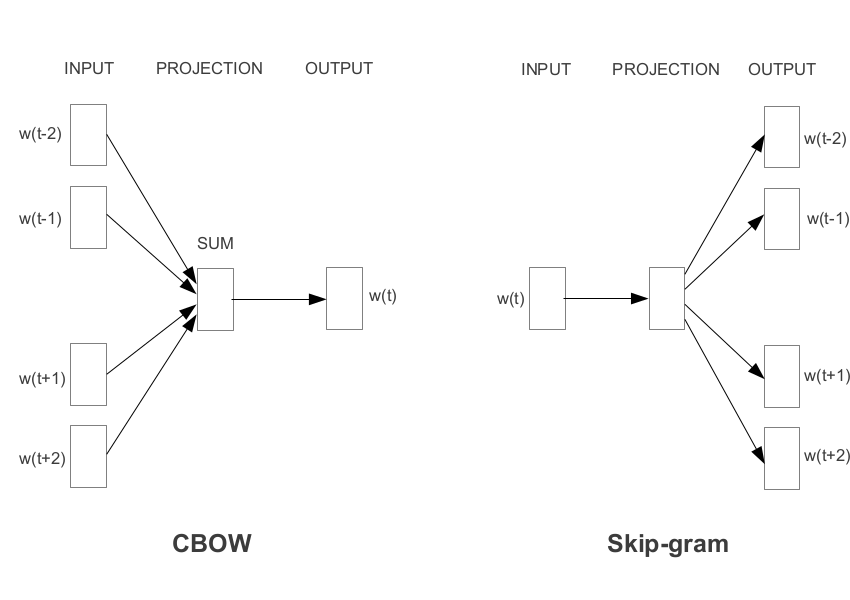

([source](https://arxiv.org/abs/1301.3781))

Skip-gram is the more widely used variant (and the one the next tutorial's `node2vec` is built on). We'll train it with [gensim](https://radimrehurek.com/gensim/), which provides a one-call `Word2Vec` trainer, and then load the resulting vectors into `nn.Embedding.from_pretrained` so the rest of the pipeline stays in PyTorch.

In [10]:
from gensim.models import Word2Vec

# gensim expects an iterable of token lists. We re-tokenise the raw training texts so
# that gensim sees the original words rather than our truncated, <unk>-replaced indices.
sentences = [tokenize(ex["text"]) for ex in train_ds]

W2V_EMBED_DIM = 64

# sg=1 selects skip-gram (sg=0 would be CBOW); negative=5 turns on negative sampling
w2v = Word2Vec(
    sentences,
    vector_size=W2V_EMBED_DIM,
    window=5,
    min_count=1,
    sg=1,
    negative=5,
    epochs=3,
    workers=4,
    seed=0,
)
print(f"trained word2vec on {len(sentences)} reviews, gensim vocabulary size {len(w2v.wv)}")

trained word2vec on 4000 reviews, gensim vocabulary size 37749


In [11]:
# Inspect what the model has learned: gensim exposes most_similar out of the box.
for word in ["bad", "great", "love", "actor", "boring"]:
    if word in w2v.wv:
        print(f"{word:>8s} -> {[(w, round(s, 3)) for w, s in w2v.wv.most_similar(word, topn=5)]}")

     bad -> [('terrible', 0.893), ('awful', 0.886), ('poor', 0.878), ('stupid', 0.878), ('horrible', 0.871)]
   great -> [('wonderful', 0.929), ('fantastic', 0.909), ('fine', 0.905), ('terrific', 0.901), ('talented', 0.891)]
    love -> [('friendship', 0.819), ('family', 0.812), ('telling', 0.811), ('difference', 0.807), ('happiness', 0.807)]
   actor -> [('actress', 0.927), ('oscar', 0.903), ('award', 0.888), ('writer', 0.886), ('role', 0.876)]
  boring -> [('gory', 0.955), ('pathetic', 0.955), ('lame', 0.955), ('dull', 0.953), ('pointless', 0.952)]


We can now build an LSTM classifier that uses the word2vec embeddings instead of learning them from scratch. We pass the trained weights to `nn.Embedding.from_pretrained` and freeze them &mdash; only the LSTM and the classification head are trained.

In [12]:
# Build a weight matrix aligned with our vocab order, copying vectors for words that
# gensim has learned and leaving rows of zeros for any vocab token gensim didn't see
# (e.g. <pad>, <unk>).
weights = torch.zeros(len(vocab), W2V_EMBED_DIM)
for word, idx in vocab.items():
    if word in w2v.wv:
        weights[idx] = torch.tensor(w2v.wv[word])

class W2VLSTMClassifier(nn.Module):
    def __init__(self, weights, hidden_size=128, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(weights, freeze=True, padding_idx=PAD)
        self.lstm = nn.LSTM(weights.size(1), hidden_size, batch_first=True)
        self.head = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        _, (h_n, _) = self.lstm(emb)
        return self.head(h_n.squeeze(0))

torch.manual_seed(0)
w2v_lstm = W2VLSTMClassifier(weights)
train_model(w2v_lstm, epochs=3)
w2v_lstm_test_loss, w2v_lstm_test_acc = calculate_loss_accuracy(w2v_lstm, dl_test)
print(f"LSTM (frozen w2v embeddings) test accuracy: {w2v_lstm_test_acc:.3f}")

epoch  1/ 3  val loss: 0.6935  val acc: 0.495
epoch  2/ 3  val loss: 0.6963  val acc: 0.494
epoch  3/ 3  val loss: 0.6916  val acc: 0.502
LSTM (frozen w2v embeddings) test accuracy: 0.503


## Attention

Even with LSTMs, every token in the sequence has to be summarised into a single fixed-size hidden state. For long inputs, this is a bottleneck. Attention solves this by letting every position in the output look directly at every position in the input.

Concretely, given three matrices

- queries $Q \in \mathbb{R}^{n \times d_k}$,
- keys $K \in \mathbb{R}^{m \times d_k}$,
- values $V \in \mathbb{R}^{m \times d_v}$,

scaled dot-product attention is defined as

$$\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\!\left(\frac{Q K^\top}{\sqrt{d_k}}\right) V.$$

Intuitively, each query is compared against every key (the dot product), the result is normalised into a probability distribution (softmax), and that distribution is used to pool the values. The $\sqrt{d_k}$ rescaling keeps the dot products from growing too large in higher dimensions, where they would push softmax into a very low-entropy regime.

For a complete walkthrough, see [The Illustrated Transformer](https://jalammar.github.io/illustrated-transformer/).

### Task 2

Implement scaled dot-product attention. Your function should accept tensors `Q`, `K`, `V` (with batch and head dimensions on the left) and an optional boolean `mask` whose `False` entries indicate positions that should *not* be attended to (e.g. padding). Return the attended output.

In [13]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    # Q, K: (..., n, d_k), V: (..., m, d_v)
    d_k = Q.size(-1)
    scores = Q @ K.transpose(-2, -1) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(~mask, float("-inf"))
    attn = scores.softmax(dim=-1)
    return attn @ V

### Multi-head attention

A single attention computation produces one weighted average of the values. *Multi-head* attention runs $h$ independent attention computations in parallel on different linear projections of $Q$, $K$, $V$, and concatenates the outputs. Each head can specialise on a different kind of relationship (e.g. one head might track subject-verb agreement, another long-range coreference).

PyTorch includes `nn.MultiheadAttention`, but let's write our own example:

In [14]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, nhead):
        super().__init__()
        assert d_model % nhead == 0
        self.nhead = nhead
        self.d_head = d_model // nhead
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, x, key_padding_mask=None):
        # x: (batch, seq, d_model)
        B, T, _ = x.shape
        def split_heads(t):
            return t.view(B, T, self.nhead, self.d_head).transpose(1, 2)
        Q = split_heads(self.W_q(x))
        K = split_heads(self.W_k(x))
        V = split_heads(self.W_v(x))
        # mask shape: (batch, 1, 1, seq) so it broadcasts over heads and queries
        mask = None
        if key_padding_mask is not None:
            mask = key_padding_mask[:, None, None, :]
        out = scaled_dot_product_attention(Q, K, V, mask=mask)
        out = out.transpose(1, 2).contiguous().view(B, T, -1)
        return self.W_o(out)

### Positional encoding

Attention is permutation-invariant: shuffling the input tokens gives the same output (just permuted). To inject the notion of *order*, the original Transformer adds a sinusoidal positional encoding to the input embeddings:

$$\mathrm{PE}(t, 2i) = \sin(t / 10000^{2i/d}), \qquad \mathrm{PE}(t, 2i+1) = \cos(t / 10000^{2i/d}).$$


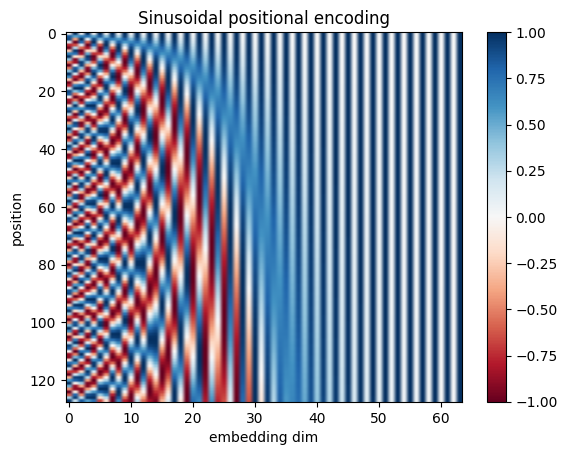

In [15]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, : x.size(1)]

# Quick visualisation
pe = PositionalEncoding(64, max_len=128).pe.squeeze(0).numpy()
plt.imshow(pe, aspect="auto", cmap="RdBu")
plt.xlabel("embedding dim")
plt.ylabel("position")
plt.title("Sinusoidal positional encoding")
plt.colorbar()
plt.show()

### Transformer encoder block

A transformer encoder block has two sub-layers:

1. multi-head self-attention,
2. a position-wise feed-forward network (two linear layers with a non-linearity in between).

Each sub-layer is wrapped in a residual connection and layer normalisation:

$$\mathrm{LayerNorm}(x + \mathrm{Sublayer}(x)).$$

### Task 3

Implement a transformer encoder block as an `nn.Module`. It should accept an input of shape `(batch, seq_len, d_model)` and an optional `key_padding_mask`, apply self-attention with a residual connection and LayerNorm, then a feed-forward block with another residual connection and LayerNorm, and return a tensor of the same shape.


In [16]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, nhead, dim_ff, dropout=0.1):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, nhead)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, dim_ff),
            nn.ReLU(),
            nn.Linear(dim_ff, d_model),
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, key_padding_mask=None):
        attn_out = self.attn(x, key_padding_mask=key_padding_mask)
        x = self.norm1(x + self.dropout(attn_out))
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_out))
        return x

Now we can assemble a sentiment classifier from a stack of encoder blocks. We pool the encoder outputs by taking the mean over non-padding positions and pass the result through a linear head.

In [17]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=64, nhead=4, dim_ff=128, num_layers=2, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD)
        self.pos = PositionalEncoding(d_model, max_len=SEQ_LEN)
        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(d_model, nhead, dim_ff) for _ in range(num_layers)
        ])
        self.head = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # key_padding_mask: True at positions to keep, False at padding
        mask = x != PAD
        h = self.pos(self.embedding(x))
        for block in self.blocks:
            h = block(h, key_padding_mask=mask)
        # Mean-pool over non-padding tokens
        mask_f = mask.unsqueeze(-1).float()
        pooled = (h * mask_f).sum(1) / mask_f.sum(1).clamp(min=1)
        return self.head(pooled)

torch.manual_seed(0)
tr_model = TransformerClassifier(len(vocab))
train_model(tr_model, epochs=3)
tr_test_loss, tr_test_acc = calculate_loss_accuracy(tr_model, dl_test)
print(f"Transformer test accuracy: {tr_test_acc:.3f}")

epoch  1/ 3  val loss: 0.6917  val acc: 0.583
epoch  2/ 3  val loss: 0.5617  val acc: 0.715
epoch  3/ 3  val loss: 0.5077  val acc: 0.756
Transformer test accuracy: 0.748


## Fine-tuning a pre-trained transformer

Modern NLP rarely trains a model from scratch on a small dataset. Instead, you take a transformer that has been pre-trained on enormous quantities of text (predicting masked tokens or next tokens) and *fine-tune* it on your downstream task. The pre-training objective forces the model to learn rich, general representations of language that transfer well, even with very little task-specific data.

We'll use [DistilBERT](https://huggingface.co/distilbert/distilbert-base-uncased) &mdash; a small, distilled variant of BERT &mdash; from the [HuggingFace `transformers`](https://huggingface.co/docs/transformers) library. DistilBERT comes with its own *WordPiece* tokeniser, which is much smarter than our `re.findall` approach: it splits unknown words into sub-word units, so the vocabulary stays manageable while still covering arbitrary text.

In [18]:
MODEL_NAME = "distilbert/distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# A small example so we can see what the tokeniser produces
example = train_ds[0]["text"][:100]
print("Input:", example)
print("Tokens:", tokenizer.tokenize(example))
print("IDs:", tokenizer(example, truncation=True, max_length=20)["input_ids"])

Input: This movie is just truly awful, the eye-candy that plays Ben just can make up for everything else th
Tokens: ['this', 'movie', 'is', 'just', 'truly', 'awful', ',', 'the', 'eye', '-', 'candy', 'that', 'plays', 'ben', 'just', 'can', 'make', 'up', 'for', 'everything', 'else', 'th']
IDs: [101, 2023, 3185, 2003, 2074, 5621, 9643, 1010, 1996, 3239, 1011, 9485, 2008, 3248, 3841, 2074, 2064, 2191, 2039, 102]


### Putting it all together

We build a `Dataset` that, for each review, returns a dictionary with `input_ids`, `attention_mask`, and `labels`. Use the DistilBERT tokeniser with `max_length=128`, `truncation=True`, and `padding="max_length"`. Then wrap it in a `DataLoader`.


In [19]:
BERT_MAX_LEN = 128

class BertIMDBDataset(Dataset):
    def __init__(self, hf_split, tokenizer, max_len=BERT_MAX_LEN):
        enc = tokenizer(
            [ex["text"] for ex in hf_split],
            truncation=True,
            padding="max_length",
            max_length=max_len,
            return_tensors="pt",
        )
        self.input_ids = enc["input_ids"]
        self.attention_mask = enc["attention_mask"]
        self.labels = torch.tensor([ex["label"] for ex in hf_split], dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        return {
            "input_ids": self.input_ids[i],
            "attention_mask": self.attention_mask[i],
            "labels": self.labels[i],
        }

# Use a smaller subset so fine-tuning is feasible without a GPU
bert_train = BertIMDBDataset(train_ds.select(range(500)), tokenizer)
bert_test = BertIMDBDataset(test_ds.select(range(200)), tokenizer)

bert_dl_train = DataLoader(bert_train, batch_size=16, shuffle=True)
bert_dl_test = DataLoader(bert_test, batch_size=16)

We can now load DistilBERT with a classification head and fine-tune it. The HuggingFace model returns a structured output object whose `loss` field is computed automatically when we pass `labels`.

In [ ]:
torch.manual_seed(0)
bert = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
opt = torch.optim.AdamW(bert.parameters(), lr=5e-5)

bert.train()
for epoch in range(1):
    for batch in bert_dl_train:
        out = bert(**batch)
        out.loss.backward()
        opt.step()
        opt.zero_grad()
    print(f"epoch {epoch+1} done")

bert.eval()
correct, total = 0, 0
with torch.no_grad():
    for batch in bert_dl_test:
        logits = bert(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"]).logits
        correct += (logits.argmax(1) == batch["labels"]).sum().item()
        total += batch["labels"].numel()
print(f"DistilBERT test accuracy: {correct / total:.3f}  (on {total} examples)")

Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 12124.02it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downst

Notice that DistilBERT, fine-tuned on only 500 reviews for one epoch, typically beats both our LSTM and our small from-scratch transformer trained on 4&thinsp;000 reviews for three epochs. That's the power of pre-training.